In [1]:
# Cell 1: Dataset Imbalanced
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 465.2 kB/s eta 0:00:00
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
   ---------------------------------------- 0.0/309.1 kB ? eta -:--:--
   ----- ---------------------------------- 41.0/309.1 kB ? eta -:--:--
   -------------- ------------------------- 112.6/309.1 kB 3.3 MB/s eta 0:00:01
   ------------------------------ --------- 2


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Cell 2: Imports
%pip install opencv-python matplotlib tensorflow

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Us

In [9]:
# Cell 3: Configuration
DATASET_PATH = r"C:\deep learning for medical imaging\busi dataset\Dataset_BUSI_with_GT"

classes = ["benign", "malignant", "normal"]
IMG_SIZE = 128

In [10]:
import os

print("Dataset path:", DATASET_PATH)
print("Exists?", os.path.exists(DATASET_PATH))

for c in ["benign", "malignant", "normal"]:
    class_path = os.path.join(DATASET_PATH, c)
    print(f"{c} folder exists?", os.path.exists(class_path))
    if os.path.exists(class_path):
        print(f"   Number of files: {len(os.listdir(class_path))}")

Dataset path: C:\deep learning for medical imaging\busi dataset\Dataset_BUSI_with_GT
Exists? True
benign folder exists? True
   Number of files: 891
malignant folder exists? True
   Number of files: 421
normal folder exists? True
   Number of files: 266


In [11]:
# Cell 4: Load Dataset
images = []
labels = []

for c in classes:
    path = os.path.join(DATASET_PATH, c)
    
    for img in os.listdir(path):
        if "_mask" in img:
            continue
            
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        
        images.append(image)
        labels.append(c)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:", X.shape)

Dataset shape: (780, 128, 128, 3)


In [12]:
# Cell 5: Encode Labels
le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [13]:
# Cell 6: Train-Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, 
    random_state=42
)

In [14]:
# Cell 7: Validation-Test Split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [15]:
# Cell 8: Depthwise Separable Block
def depthwise_separable_block(x, filters, strides=(1, 1)):
    # Depthwise Convolution
    x = DepthwiseConv2D((3, 3), strides=strides, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Pointwise Convolution (1x1)
    x = Conv2D(filters, (1, 1), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    return x

In [16]:
# Cell 9: Create Model
def create_model():
    inputs = Input(shape=(128, 128, 3))

    # Initial Conv
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Depthwise Separable Blocks
    x = depthwise_separable_block(x, 64)
    x = depthwise_separable_block(x, 128, strides=(2, 2))
    x = depthwise_separable_block(x, 128)

    x = depthwise_separable_block(x, 256, strides=(2, 2))
    x = depthwise_separable_block(x, 256)

    x = depthwise_separable_block(x, 512, strides=(2, 2))

    for _ in range(3):
        x = depthwise_separable_block(x, 512)

    x = depthwise_separable_block(x, 1024, strides=(2, 2))
    x = depthwise_separable_block(x, 1024)

    # Classification Head
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
# Cell 10: Train Imbalanced Model
model_imbalanced = create_model()

history_imbalanced = model_imbalanced.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16
)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.4963 - loss: 1.0616 - val_accuracy: 0.2735 - val_loss: 1.0890
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 0.5586 - loss: 0.9668 - val_accuracy: 0.2735 - val_loss: 1.0892
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 497ms/step - accuracy: 0.5897 - loss: 0.9001 - val_accuracy: 0.2735 - val_loss: 1.1057
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 522ms/step - accuracy: 0.5989 - loss: 0.9206 - val_accuracy: 0.2735 - val_loss: 1.1152
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 500ms/step - accuracy: 0.6099 - loss: 0.8584 - val_accuracy: 0.2735 - val_loss: 1.1467
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - accuracy: 0.6410 - loss: 0.8081 - val_accuracy: 0.2735 - val_loss: 1.1918
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.6685 - loss: 0.7823 - val_accuracy: 0.2735 - val_loss: 1.2470
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.7106 - loss: 0.6864 - val_accuracy

In [18]:
# Cell 11: Evaluate Imbalanced Model
y_pred = model_imbalanced.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

acc1 = accuracy_score(y_test, y_pred_classes)
prec1 = precision_score(y_test, y_pred_classes, average="weighted")
rec1 = recall_score(y_test, y_pred_classes, average="weighted")
f11 = f1_score(y_test, y_pred_classes, average="weighted")

print("IMBALANCED MODEL RESULTS")
print("Accuracy: ", acc1)
print("Precision:", prec1)
print("Recall:   ", rec1)
print("F1 Score: ", f11)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step
IMBALANCED MODEL RESULTS
Accuracy:  0.5641025641025641
Precision: 0.5530391930391931
Recall:    0.5641025641025641
F1 Score:  0.5557515583831373

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67        66
           1       0.52      0.42      0.46        31
           2       0.33      0.30      0.32        20

    accuracy                           0.56       117
   macro avg       0.50      0.48      0.48       117
weighted avg       0.55      0.56      0.56       117



In [19]:
# Cell 12: Apply SMOTE
X_train_flat = X_train.reshape(len(X_train), -1)

sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X_train_flat, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE: ", np.bincount(y_smote))

Before SMOTE: [306 147  93]
After SMOTE:  [306 306 306]


In [20]:
# Cell 13: Reshape SMOTE Data
X_smote = X_smote.reshape(-1, 128, 128, 3)

In [22]:
# Cell 14: Train SMOTE Model
model_smote = create_model()

history_smote = model_smote.fit(
    X_smote,
    y_smote,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 253ms/step - accuracy: 0.4739 - loss: 1.0424 - val_accuracy: 0.1709 - val_loss: 1.1955
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - accuracy: 0.5153 - loss: 0.9779 - val_accuracy: 0.1709 - val_loss: 1.3106
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 408ms/step - accuracy: 0.5752 - loss: 0.9024 - val_accuracy: 0.1709 - val_loss: 1.5849
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 494ms/step - accuracy: 0.5741 - loss: 0.8723 - val_accuracy: 0.2735 - val_loss: 1.9624
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 453ms/step - accuracy: 0.6285 - loss: 0.8312 - val_accuracy: 0.1709 - val_loss: 2.0493
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 410ms/step - accuracy: 0.6863 - loss: 0.7377 - val_accuracy: 0.1709 - val_loss: 2.4316
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 290ms/step - accuracy: 0.7876 - loss: 0.5587 - val_accuracy: 0.1709 - val_loss: 2.9238
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 269ms/step - accuracy: 0.8290 - loss: 0.4443 - val_accu

In [23]:
# Cell 15: Evaluate SMOTE Model
y_pred = model_smote.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

acc2 = accuracy_score(y_test, y_pred_classes)
prec2 = precision_score(y_test, y_pred_classes, average="weighted")
rec2 = recall_score(y_test, y_pred_classes, average="weighted")
f12 = f1_score(y_test, y_pred_classes, average="weighted")

print("SMOTE MODEL RESULTS")
print("Accuracy: ", acc2)
print("Precision:", prec2)
print("Recall:   ", rec2)
print("F1 Score: ", f12)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step
SMOTE MODEL RESULTS
Accuracy:  0.5982905982905983
Precision: 0.5988742964352721
Recall:    0.5982905982905983
F1 Score:  0.5651899554338579

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.83      0.74        66
           1       0.60      0.19      0.29        31
           2       0.36      0.45      0.40        20

    accuracy                           0.60       117
   macro avg       0.54      0.49      0.48       117
weighted avg       0.60      0.60      0.57       117



In [24]:
# Cell 16: Final Comparison
print("\nFINAL COMPARISON")
print("Imbalanced Model")
print(f"Accuracy : {acc1:.4f}")
print(f"Precision: {prec1:.4f}")
print(f"Recall   : {rec1:.4f}")
print(f"F1 Score : {f11:.4f}")

print("\nSMOTE Balanced Model")
print(f"Accuracy : {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall   : {rec2:.4f}")
print(f"F1 Score : {f12:.4f}")


FINAL COMPARISON
Imbalanced Model
Accuracy : 0.5641
Precision: 0.5530
Recall   : 0.5641
F1 Score : 0.5558

SMOTE Balanced Model
Accuracy : 0.5983
Precision: 0.5989
Recall   : 0.5983
F1 Score : 0.5652


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


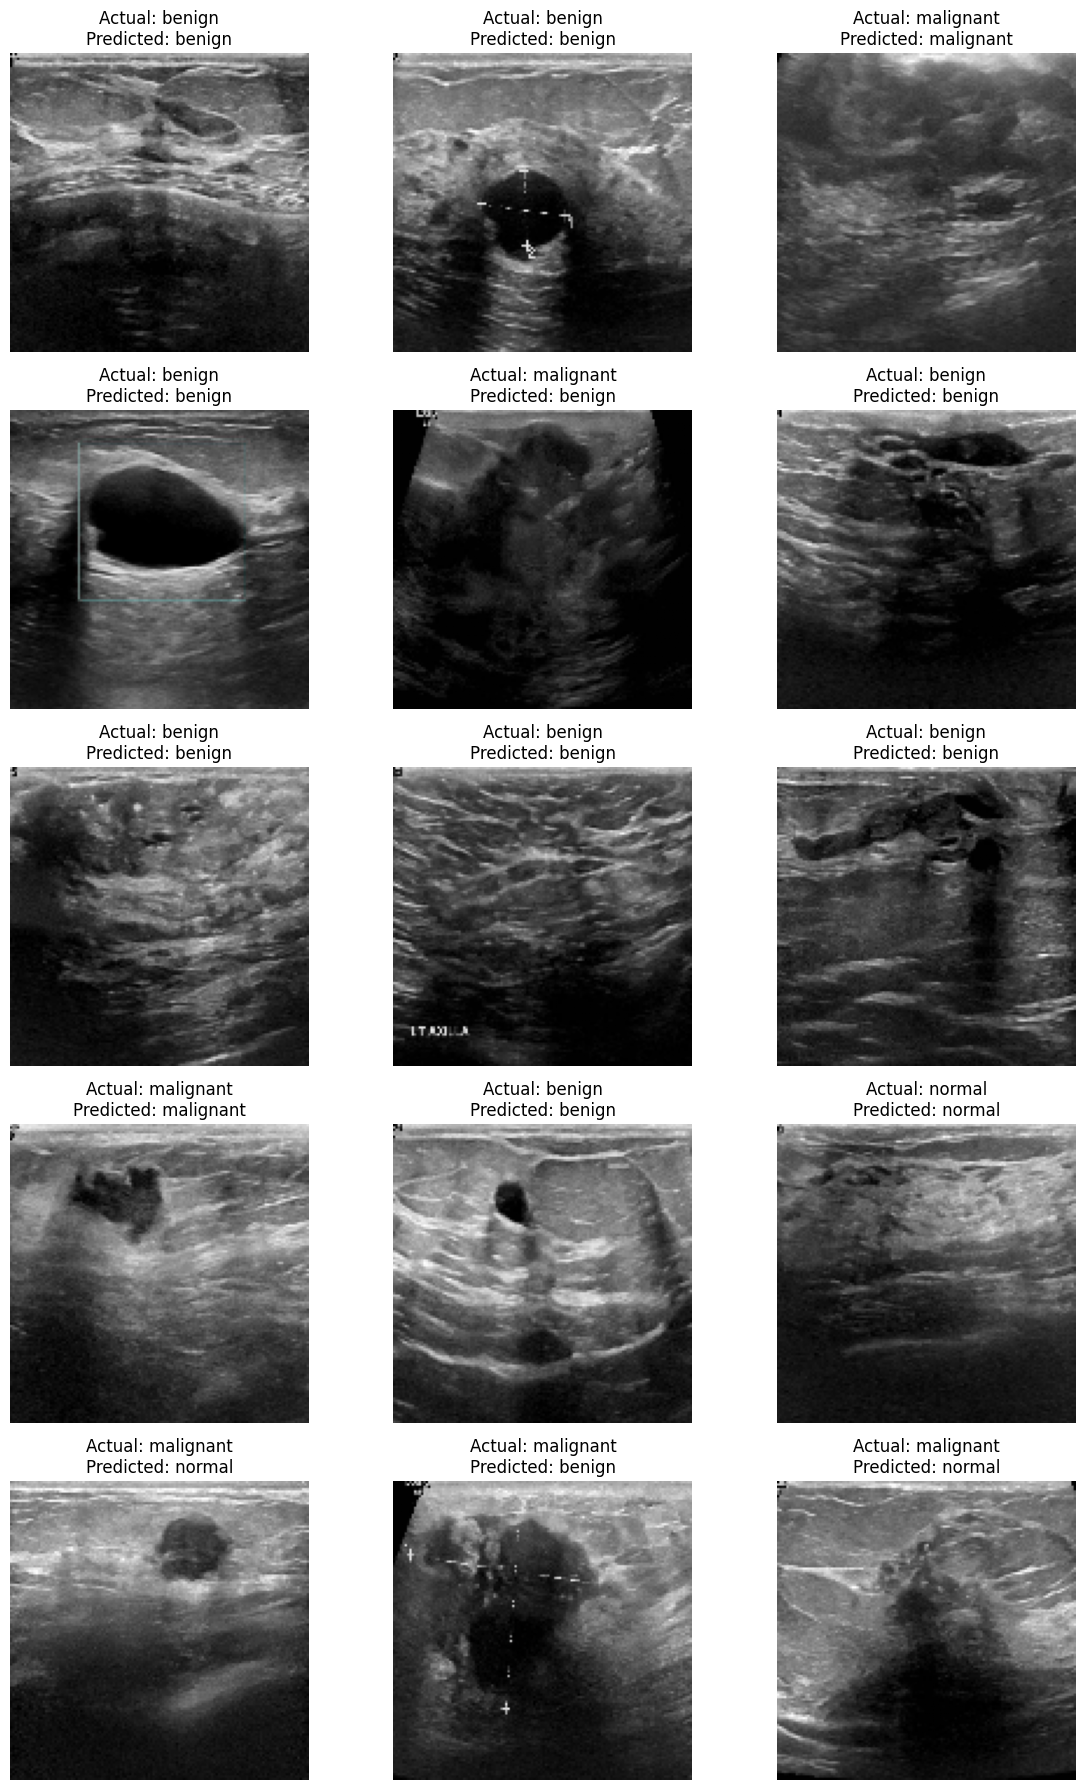

In [25]:
# Cell 17: Visualization of Predictions (using SMOTE model)
num_images = 15
indices = np.random.choice(len(X_test), num_images, replace=False)

sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = model_smote.predict(sample_images)
pred_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 18))

for i in range(num_images):
    ax = plt.subplot(5, 3, i + 1)
    ax.axis("off")

    actual = le.classes_[sample_labels[i]]
    predicted = le.classes_[pred_classes[i]]

    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.imshow(sample_images[i])

plt.tight_layout()
plt.show()